In [2]:
import numpy as np
import os
import xarray as xr
import glob
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
import dask.array as da
import pickle
from scipy.stats import t
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [3]:
with open('/home/annierosen16/master_w_sp_2001_2025.pkl', 'rb') as f:
    
    master = pickle.load(f)

In [4]:
with open('/home/annierosen16/pressure.pkl', 'rb') as f:
    
    pressure = pickle.load(f)
    
with open('/home/annierosen16/sgp_latitudes.pkl', 'rb') as f:
    
    latitude = pickle.load(f)
    
with open('/home/annierosen16/sgp_longitudes.pkl', 'rb') as f:
    
    longitude = pickle.load(f)

In [5]:
all_layers_df = pd.read_pickle("/home/annierosen16/all_layers_df.pkl")

In [6]:
diurnal_q_df = (
    
    all_layers_df.groupby(['date', 'lat', 'lon']).agg({
        
        'int_q': list,
        
        'bl_int_q': list,
        
        'lt_int_q': list
    
    })
    
    .reset_index()
    
    .rename(columns={
        
        'int_q': 'diurnal_q',
        
        'bl_int_q': 'diurnal_bl_q',
        
        'lt_int_q': 'diurnal_lt_q'
    })
)

In [7]:
def diurnal_derivative(q_list):
    
    q_array = np.array(q_list)
    
    # central differences when possible, uses 2*dt_hours = 6
    
    # for edge points, uses dt_hours
    
    dt_hours = 3
    
    dq_dt = np.gradient(q_array, dt_hours)  # mm/hour
    
    return list(dq_dt * 24)  # mm/day

In [8]:
diurnal_q_df['diurnal_dqdt'] = diurnal_q_df['diurnal_q'].apply(diurnal_derivative)

diurnal_q_df['diurnal_bl_dqdt'] = diurnal_q_df['diurnal_bl_q'].apply(diurnal_derivative)

diurnal_q_df['diurnal_lt_dqdt'] = diurnal_q_df['diurnal_lt_q'].apply(diurnal_derivative)

diurnal_q_df_renamed = diurnal_q_df.rename(columns={'lat': 'latitude', 'lon': 'longitude'})

In [9]:
master['date'] = pd.to_datetime(master['date'])

diurnal_q_df_renamed['date'] = pd.to_datetime(diurnal_q_df_renamed['date'])

master_time_tendency = master.merge(diurnal_q_df_renamed[['date', 'latitude', 'longitude', 'diurnal_q','diurnal_dqdt', 'diurnal_bl_q','diurnal_bl_dqdt', 'diurnal_lt_q', 'diurnal_lt_dqdt']],
    
                                    on=['date', 'latitude', 'longitude'],
                                    
                                    how='left')

In [10]:
## drop day = 9/30 because we are missing complete precipitation and q information for that day 

dates = pd.to_datetime(master_time_tendency["date"])

master_time_tendency = master_time_tendency[~((dates.dt.month == 9) & (dates.dt.day == 30))].copy()

In [12]:
#re-run

predryapes = master_time_tendency[master_time_tendency['predryape'] == True]

prewetapes = master_time_tendency[master_time_tendency['prewetape'] == True]

In [13]:
## define full column diurnal dqdt here

dry_stacked = np.stack(predryapes['diurnal_dqdt'].values)

diurnal_time_tendency_dry = dry_stacked.mean(axis=0)

wet_stacked = np.stack(prewetapes['diurnal_dqdt'].values)

diurnal_time_tendency_wet = wet_stacked.mean(axis=0)

In [14]:
## define BL diurnal dqdt here

bl_dry_stacked = np.stack(predryapes['diurnal_bl_dqdt'])

bl_diurnal_time_tendency_dry = bl_dry_stacked.mean(axis=0)

bl_wet_stacked = np.stack(prewetapes['diurnal_bl_dqdt'])

bl_diurnal_time_tendency_wet = bl_wet_stacked.mean(axis=0)

In [15]:
## define LT diurnal dqdt here

lt_dry_stacked = np.stack(predryapes['diurnal_lt_dqdt'])

lt_diurnal_time_tendency_dry = lt_dry_stacked.mean(axis=0)

lt_wet_stacked = np.stack(prewetapes['diurnal_lt_dqdt'])

lt_diurnal_time_tendency_wet = lt_wet_stacked.mean(axis=0)

In [22]:
with open('/home/annierosen16/diurnal_time_tendency_2001_2025_preapes.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': diurnal_time_tendency_dry,
        
        'wet': diurnal_time_tendency_wet
    
    }, f)
    
# dump boundary layer time tendency 

with open('/home/annierosen16/bl_diurnal_time_tendency_2001_2025_preapes.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': bl_diurnal_time_tendency_dry,
        
        'wet': bl_diurnal_time_tendency_wet
    
    }, f)

# dump lt time tendency 

with open('/home/annierosen16/lt_diurnal_time_tendency_2001_2025_preapes.pkl', 'wb') as f:
    
    pickle.dump({
        
        'dry': lt_diurnal_time_tendency_dry,
        
        'wet': lt_diurnal_time_tendency_wet
    
    }, f)

In [18]:
# with open('/home/annierosen16/diurnal_time_tendency.pkl', 'rb') as f:
    
#     data = pickle.load(f)

# diurnal_time_tendency_dry = list(data['dry'])

# diurnal_time_tendency_wet = list(data['wet'])

## integrated full column q

In [16]:
# apes

predryapes_cwv_stacked = np.stack(predryapes['diurnal_q'].values)

diurnal_cwv_predryapes = predryapes_cwv_stacked.mean(axis=0)

prewetapes_cwv_stacked = np.stack(prewetapes['diurnal_q'].values)

diurnal_cwv_prewetapes = prewetapes_cwv_stacked.mean(axis=0)

### integrated BL q

In [17]:
# apes

bl_predryapes_cwv_stacked = np.stack(predryapes['diurnal_bl_q'].values)

bl_diurnal_cwv_predryapes = bl_predryapes_cwv_stacked.mean(axis=0)

bl_prewetapes_cwv_stacked = np.stack(prewetapes['diurnal_bl_q'].values)

bl_diurnal_cwv_prewetapes = bl_prewetapes_cwv_stacked.mean(axis=0)

### integrated LT q

In [18]:
# apes

lt_predryapes_cwv_stacked = np.stack(predryapes['diurnal_lt_q'].values)

lt_diurnal_cwv_predryapes = lt_predryapes_cwv_stacked.mean(axis=0)

lt_prewetapes_cwv_stacked = np.stack(prewetapes['diurnal_lt_q'].values)

lt_diurnal_cwv_prewetapes = lt_prewetapes_cwv_stacked.mean(axis=0)

### plots for total CWV, boundary layer q and LT q integrated:

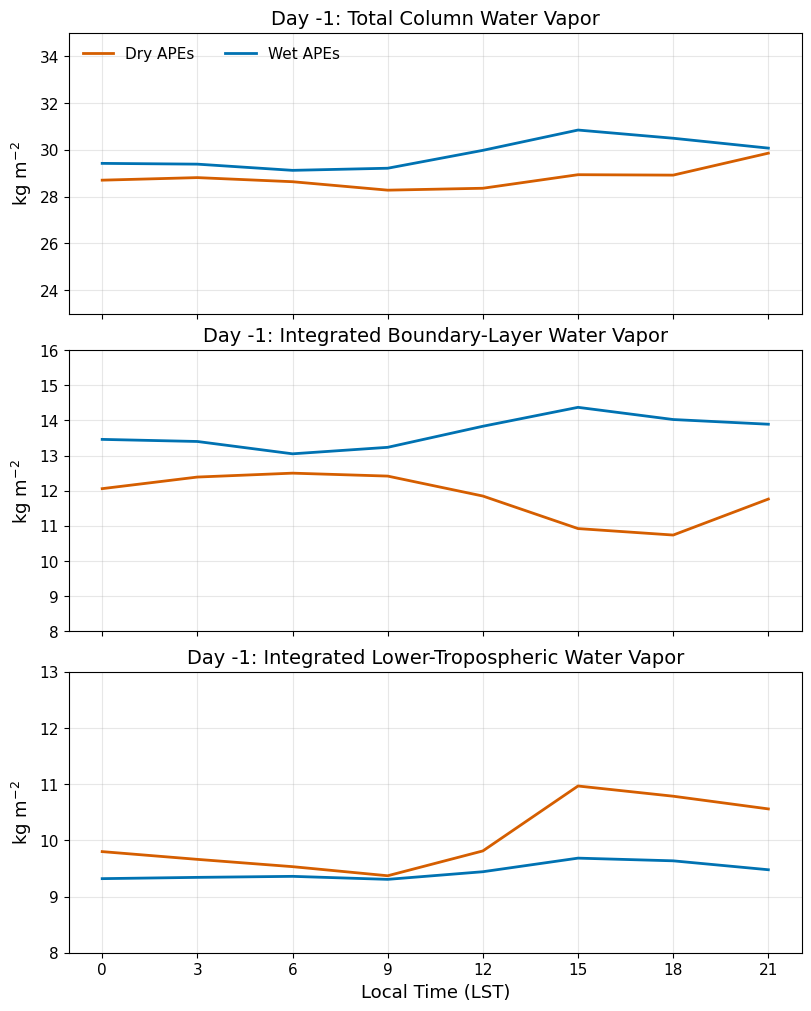

In [25]:
hours = np.arange(0, 24, 3)

COLORS = {
    
    "dry": "#D55E00",   # muted vermillion
    
    "wet": "#0072B2",   # muted blue
}

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

def plot_diurnal_cwv_3panel(hours,
                            cwv_dry, cwv_wet, 
                            bl_dry,  bl_wet,  
                            lt_dry,  lt_wet):

    COLORS = {
        "dry": "#D55E00",   # vermillion
        "wet": "#0072B2",   # blue
    }

    fig, axes = plt.subplots(
        3, 1, figsize=(8, 10),
        sharex=True, constrained_layout=True
    )
    
    panels = [
        (axes[0], cwv_dry, cwv_wet,
         "Day -1: Total Column Water Vapor", "kg m$^{-2}$", (23, 35)),
        (axes[1], bl_dry, bl_wet, 
         "Day -1: Integrated Boundary-Layer Water Vapor", "kg m$^{-2}$", (8, 16)),
        (axes[2], lt_dry, lt_wet, 
         "Day -1: Integrated Lower-Tropospheric Water Vapor", "kg m$^{-2}$", (8, 13)),
    ]

    for ax, dry, wet, title, ylabel, ylim in panels:

        ax.plot(hours, dry,
                color=COLORS["dry"],
                linewidth=2, label="Dry APEs")

        ax.plot(hours, wet,
                color=COLORS["wet"],
                linewidth=2, label="Wet APEs")

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_ylim(*ylim)   # 👈 control y-axis here
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Local Time (LST)")
    axes[-1].set_xticks(hours)

    axes[0].legend(ncol=2, frameon=False, loc="upper left")

    plt.show()


plot_diurnal_cwv_3panel(
    hours,
    diurnal_cwv_predryapes,
    diurnal_cwv_prewetapes,
    bl_diurnal_cwv_predryapes,
    bl_diurnal_cwv_prewetapes,
    lt_diurnal_cwv_predryapes,
    lt_diurnal_cwv_prewetapes,
)